In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split 

#multiple regression Algorithm
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.svm import SVR
from sklearn import metrics

In [2]:
df = pd.read_csv('/kaggle/input/datasets/adewolepaul/dsn-dataset/train.csv')
df.head()

,id,product_code,product_weight_kg,fat_content,shelf_visibility,product_category,product_price,store_code,store_age_years,store_size,store_location_tier,store_format,total_sales
0,row_00000,PRD-PRFP9S,14.252,Low Fat,0.0271,Frozen Foods,81.37,STORE-AGY,45,Large,Tier_3,Standard Supermarket,1764.98
1,row_00001,PRD-PXXK71,7.698,Low Fat,0.0720,HEALTH AND HYGIENE,42.05,STORE-YLW,35,Small,Tier_1,Standard Supermarket,342.13
2,row_00002,PRD-V5MOIJ,14.264,Regular,0.0421,Canned,41.35,STORE-89Z,33,Medium,Tier_1,Standard Supermarket,378.85
3,row_00003,PRD-UN5Z3J,NaN,Regular,0.0449,soft drinks,174.35,STORE-7WS,47,Medium,Tier_3,Flagship Hypermarket,5595.72
4,row_00004,PRD-6RDQYB,10.338,Regular,0.0120,meat,203.06,STORE-9RG,28,Small,Tier_2,Standard Supermarket,2375.36


In [3]:
df.shape

(6818, 13)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6818 entries, 0 to 6817
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   id                   6818 non-null   object 
 1   product_code         6818 non-null   object 
 2   product_weight_kg    5593 non-null   float64
 3   fat_content          6818 non-null   object 
 4   shelf_visibility     6818 non-null   float64
 5   product_category     6818 non-null   object 
 6   product_price        6818 non-null   float64
 7   store_code           6818 non-null   object 
 8   store_age_years      6818 non-null   int64  
 9   store_size           4899 non-null   object 
 10  store_location_tier  6818 non-null   object 
 11  store_format         6818 non-null   object 
 12  total_sales          6818 non-null   float64
dtypes: float64(4), int64(1), object(8)
memory usage: 692.6+ KB


In [5]:
df.isnull().sum()

id                        0
product_code              0
product_weight_kg      1225
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [6]:
print("Variance:", df['product_weight_kg'].var())
print('std:', df['product_weight_kg'].std())
print("Coefficient of Variation:", df['product_weight_kg'].std() / df['product_weight_kg'].mean())

Variance: 21.590355716002456
std: 4.646542339848251
Coefficient of Variation: 0.3615739790893106


In [7]:
# Build lookup tables from your train data
product_weight_lookup = df["product_code"].map(
    df.groupby("product_code")["product_weight_kg"].median()
)
category_weight_lookup = df.groupby("product_category")["product_weight_kg"].median()
global_weight_median = df["product_weight_kg"].median()

# fill missing weight using the SAME product's known weight from other rows
product_median_by_code = df.groupby("product_code")["product_weight_kg"].median()
mask = df["product_weight_kg"].isnull()
df.loc[mask, "product_weight_kg"] = df.loc[mask, "product_code"].map(product_median_by_code)

# fallback - fill any still-missing using the product_category median
mask = df["product_weight_kg"].isnull()
df.loc[mask, "product_weight_kg"] = df.loc[mask, "product_category"].map(category_weight_lookup)

# final safety net - fill anything still missing with the overall median
df["product_weight_kg"] = df["product_weight_kg"].fillna(global_weight_median)

# Check it worked
print(df["product_weight_kg"].isnull().sum())  

0


In [8]:
df.isnull().sum()

id                        0
product_code              0
product_weight_kg         0
fat_content               0
shelf_visibility          0
product_category          0
product_price             0
store_code                0
store_age_years           0
store_size             1919
store_location_tier       0
store_format              0
total_sales               0
dtype: int64

In [9]:
# fill missing store_size using the known size for that exact store
store_size_lookup = df.groupby("store_code")["store_size"].first()
mask = df["store_size"].isnull()
df.loc[mask, "store_size"] = df.loc[mask, "store_code"].map(store_size_lookup)

# for stores that NEVER reported a size anywhere, label as "Unknown"
df["store_size"] = df["store_size"].fillna("Unknown")

# Check it worked
print(df["store_size"].isnull().sum()) 
print(df["store_size"].value_counts())

0
store_size
Medium     2218
Small      1933
Unknown    1919
Large       748
Name: count, dtype: int64


In [10]:
df.isnull().sum()

id                     0
product_code           0
product_weight_kg      0
fat_content            0
shelf_visibility       0
product_category       0
product_price          0
store_code             0
store_age_years        0
store_size             0
store_location_tier    0
store_format           0
total_sales            0
dtype: int64

In [11]:
# Fix product_category casing
# ("DAIRY", "dairy", "Dairy" were being treated as 3 different categories - 48 fake categories, really only 16)
df['product_category'] = df['product_category'].str.strip().str.title()

print("Unique categories:", df['product_category'].nunique())  # should print 16

Unique categories: 16


In [12]:
df.describe()

,product_weight_kg,shelf_visibility,product_price,store_age_years,total_sales
count,6818.000000,6818.000000,6818.000000,6818.000000,6818.000000
mean,12.869071,0.065527,140.473623,34.178205,2174.756574
std,4.642705,0.051566,62.413513,8.384574,1697.894956
min,4.482000,0.000000,31.110000,23.000000,32.700000
25%,8.784000,0.026600,93.280000,28.000000,834.792500
50%,12.696250,0.053200,142.065000,33.000000,1790.890000
75%,16.922000,0.093400,185.987500,45.000000,3092.587500
max,21.883000,0.320100,273.040000,47.000000,12996.820000


<Figure size 600x600 with 0 Axes>

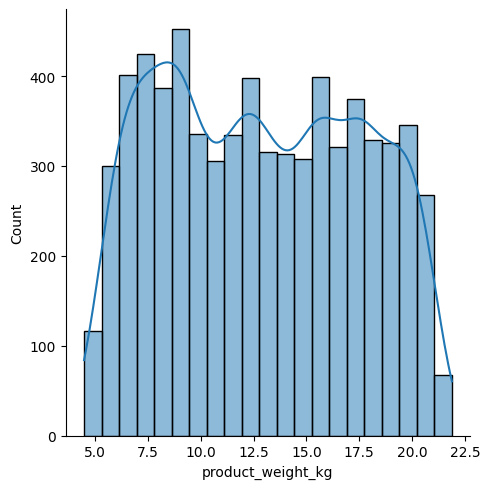

In [13]:
plt.figure(figsize=(6,6))
sns.displot(df['product_weight_kg'], kde=True)
plt.show()

<Figure size 600x600 with 0 Axes>

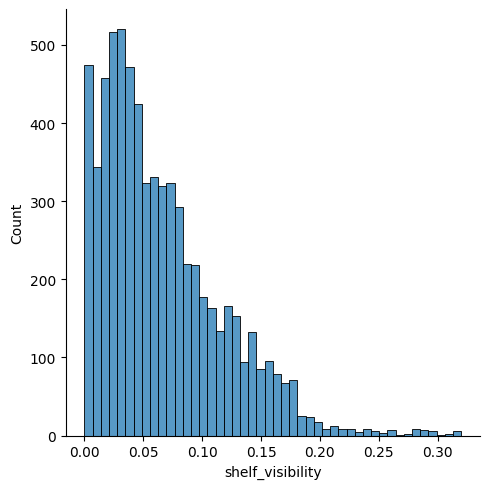

In [14]:
plt.figure(figsize=(6,6))
sns.displot(df['shelf_visibility'])
plt.show()

<Figure size 600x600 with 0 Axes>

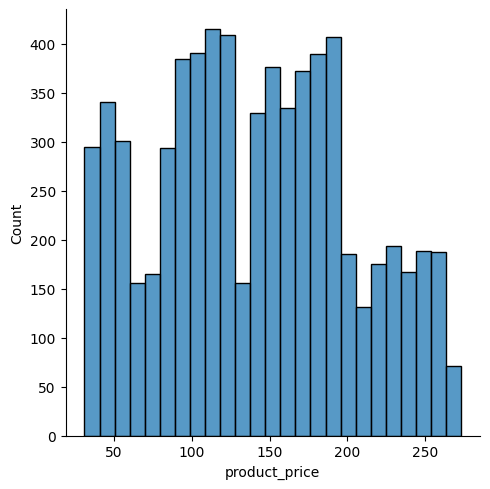

In [15]:
plt.figure(figsize=(6,6))
sns.displot(df['product_price'])
plt.show()

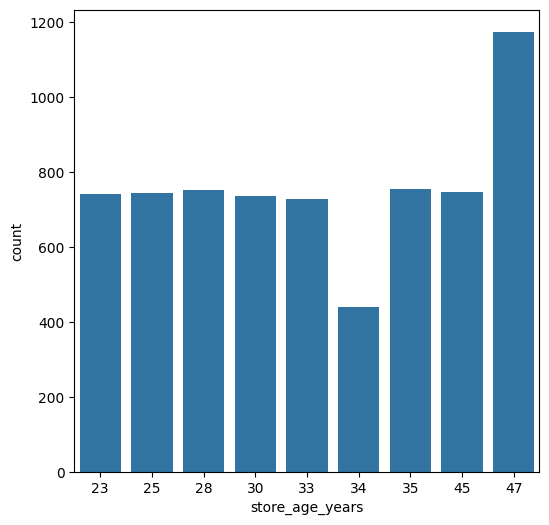

In [16]:
plt.figure(figsize=(6,6))
sns.countplot(x='store_age_years', data=df)
plt.show()

<Figure size 600x600 with 0 Axes>

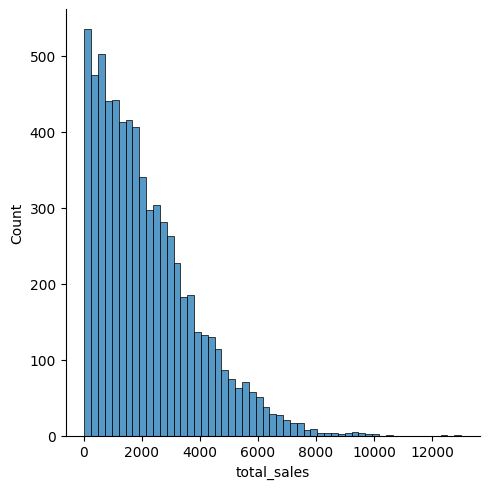

In [17]:
plt.figure(figsize=(6,6))
sns.displot(df['total_sales'])
plt.show()

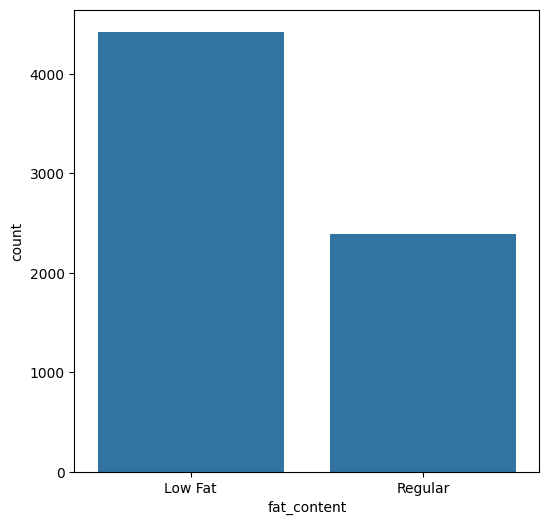

In [18]:
plt.figure(figsize=(6,6))
sns.countplot(x='fat_content', data=df)
plt.show()

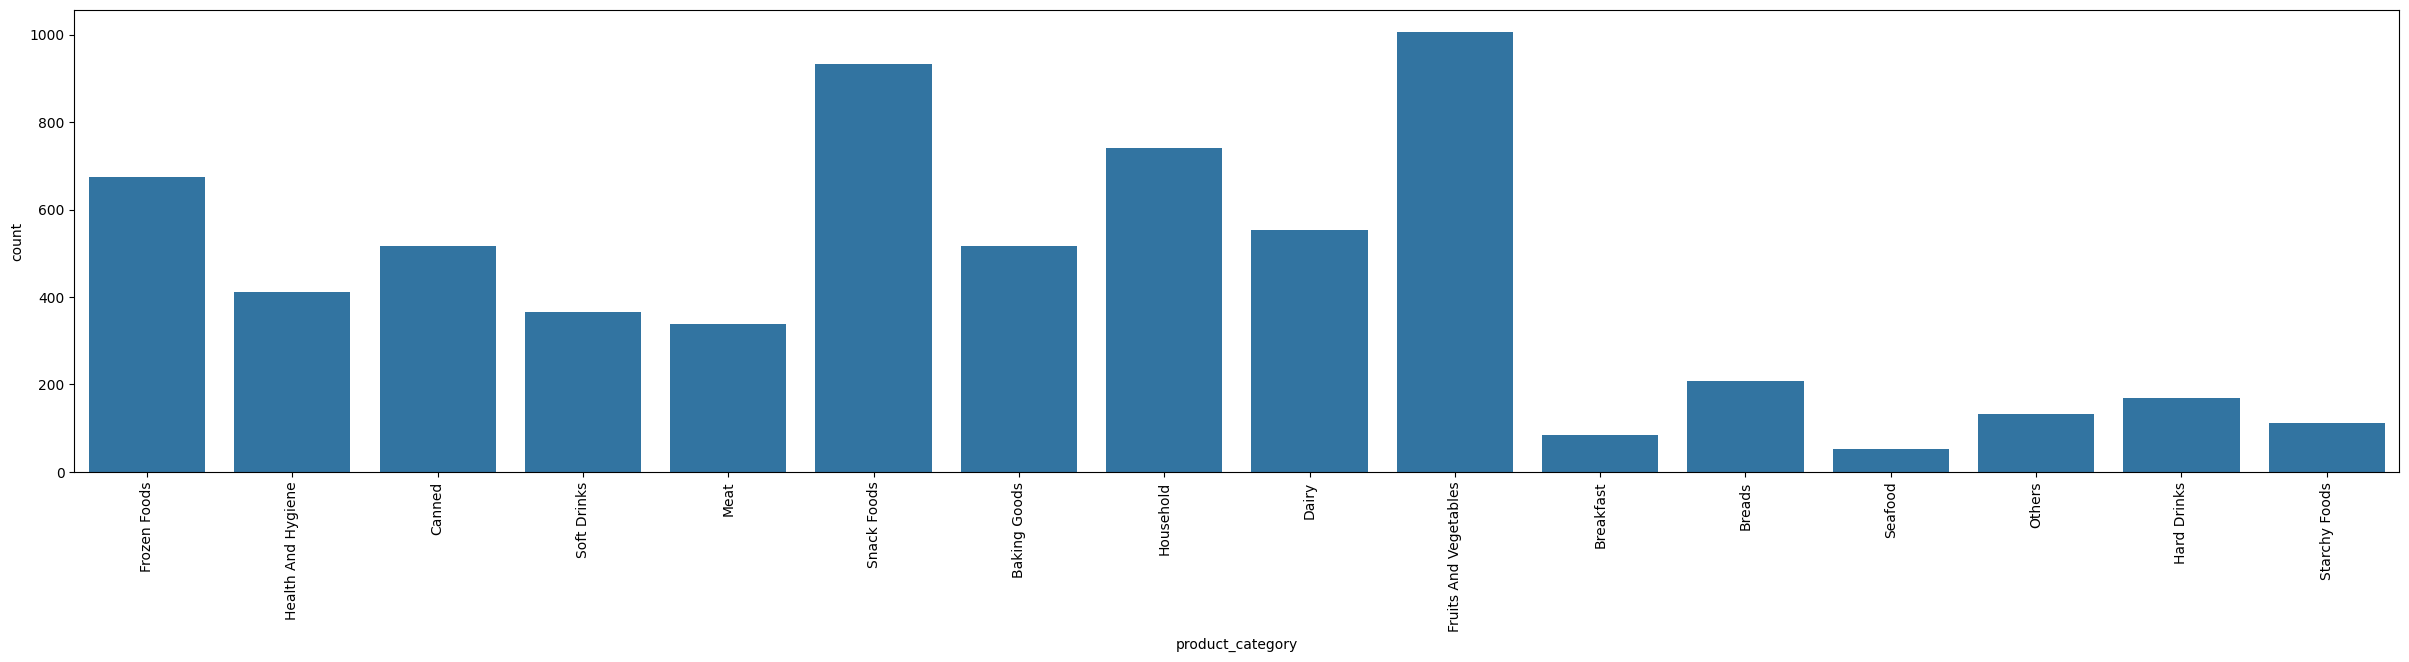

In [19]:
plt.figure(figsize=(30,6))
sns.countplot(x='product_category', data=df)
plt.xticks(rotation=90)
plt.show()

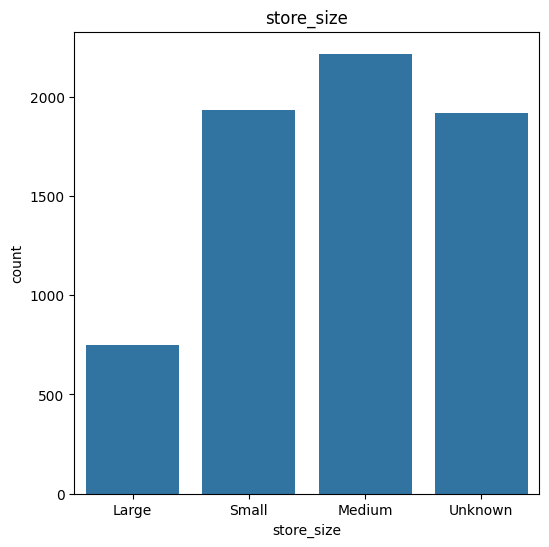

In [20]:
plt.figure(figsize=(6,6))
sns.countplot(x='store_size', data=df)
plt.title('store_size')
plt.show()


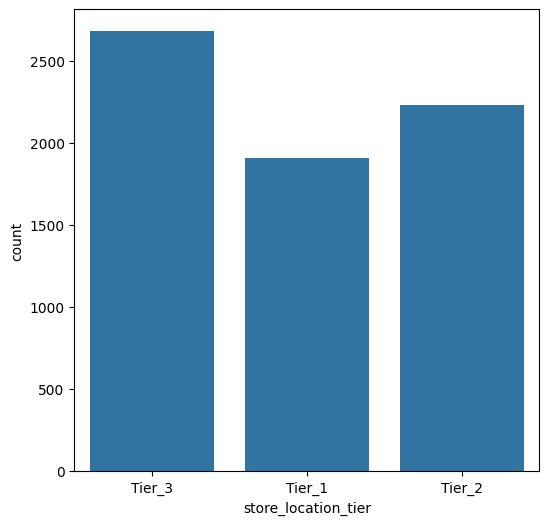

In [21]:
plt.figure(figsize=(6,6))
sns.countplot(x='store_location_tier', data=df)
plt.show()

Bivarate EDA

In [22]:
df['store_format'].value_counts()

store_format
Standard Supermarket    4462
Corner Shop              866
Flagship Hypermarket     748
Superstore               742
Name: count, dtype: int64

<Axes: xlabel='total_sales', ylabel='store_format'>

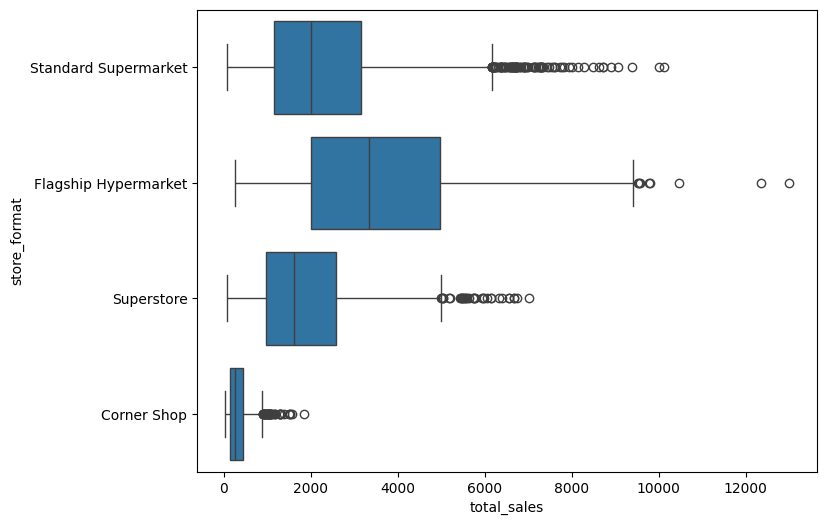

In [23]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='total_sales',
    y='store_format'
)

<Axes: xlabel='total_sales', ylabel='store_size'>

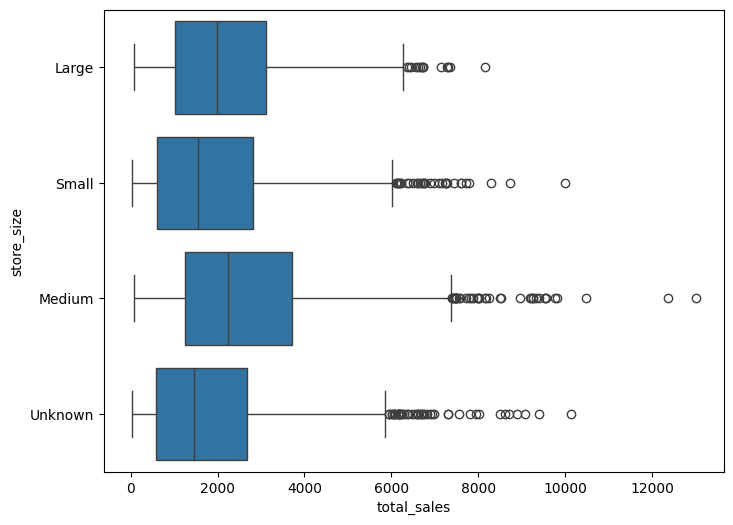

In [24]:
plt.figure(figsize=(8,6))

sns.boxplot(
    data=df,
    x='total_sales',
    y='store_size'
)

<Axes: xlabel='total_sales', ylabel='store_location_tier'>

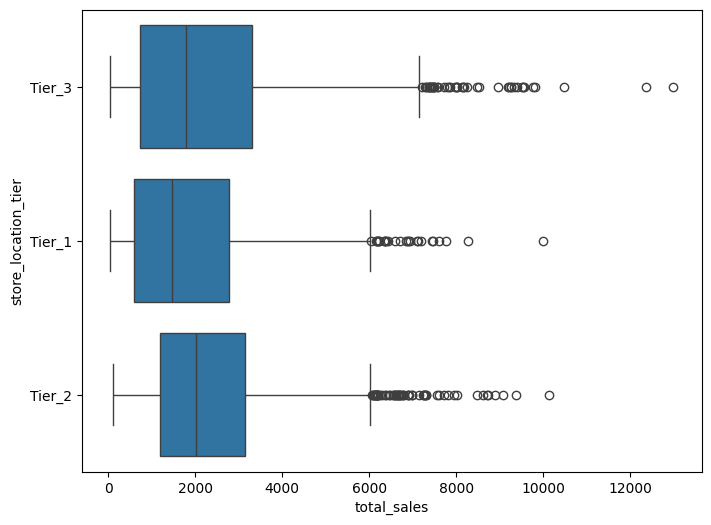

In [25]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='total_sales',
    y='store_location_tier'
)

<Axes: xlabel='total_sales', ylabel='fat_content'>

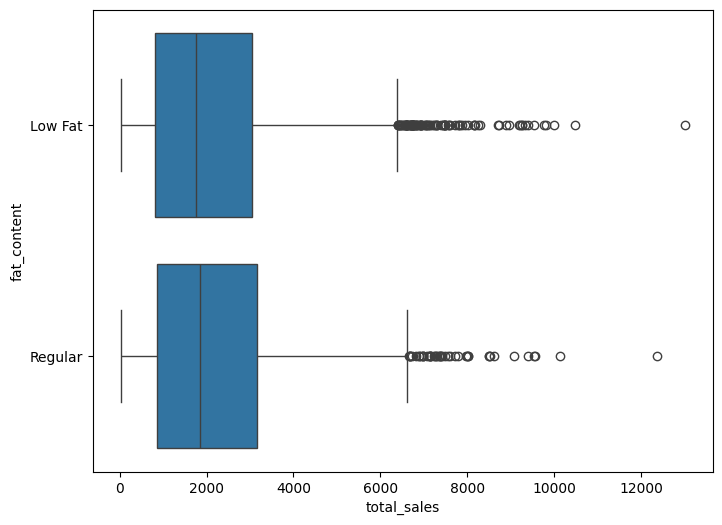

In [26]:
plt.figure(figsize=(8,6))
sns.boxplot(
    data=df,
    x='total_sales',
    y='fat_content'
)

<Axes: xlabel='total_sales', ylabel='product_category'>

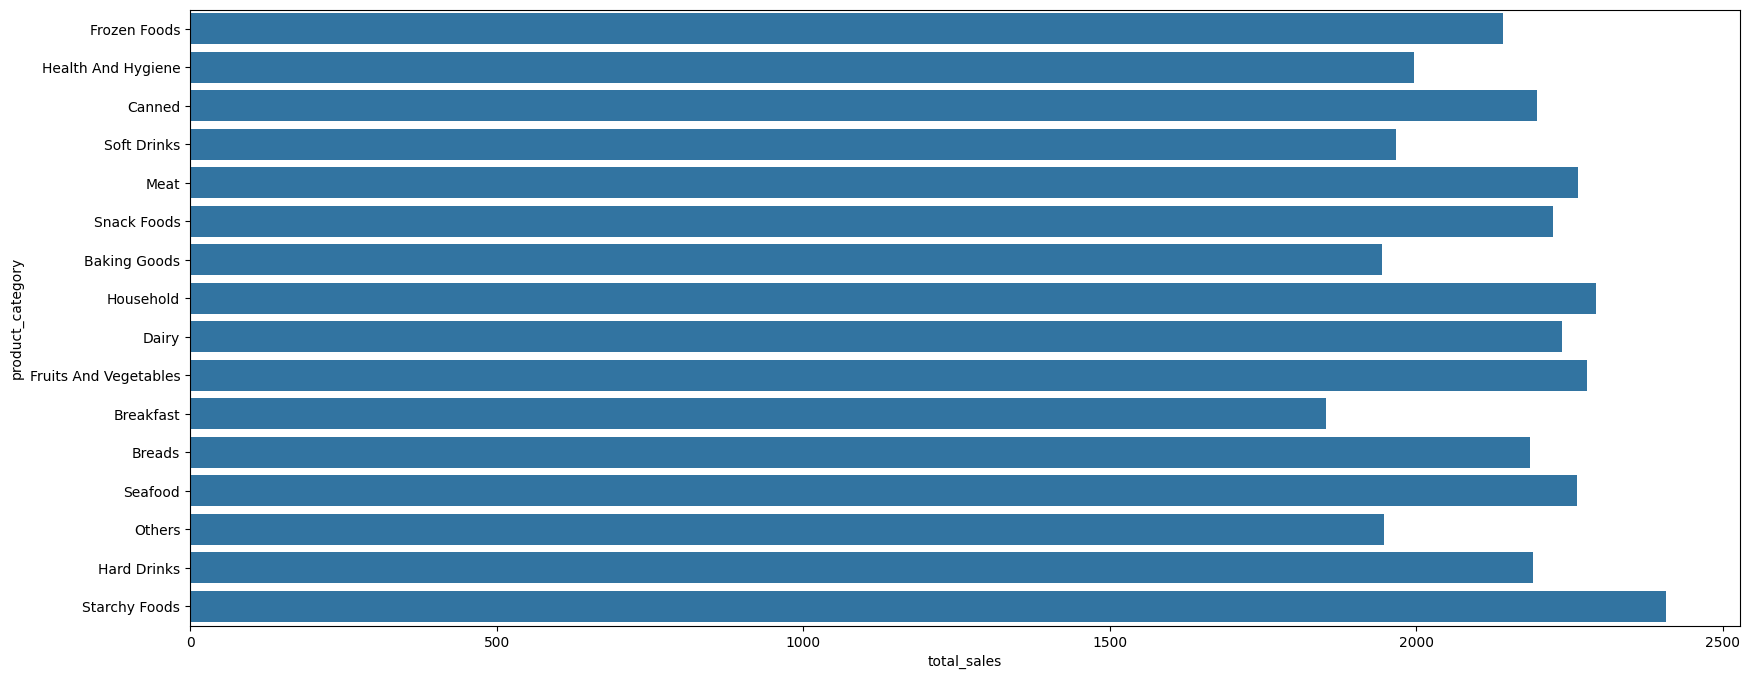

In [27]:
plt.figure(figsize=(20,8))
sns.barplot(
    data=df,
    x='total_sales',
    y='product_category',
    errorbar=None
)

<Axes: xlabel='total_sales', ylabel='shelf_visibility'>

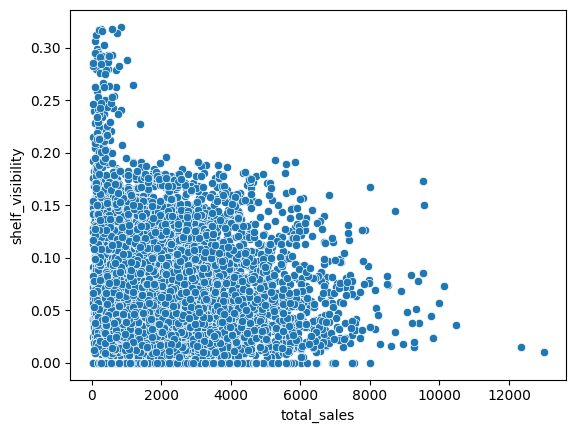

In [28]:
sns.scatterplot(
    data=df,
    x='total_sales',
    y='shelf_visibility'
)


<Axes: >

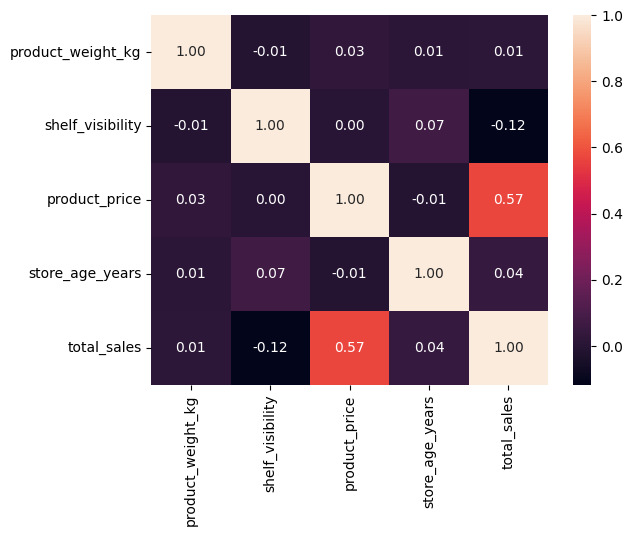

In [29]:
sns.heatmap(df.corr(numeric_only=True), annot=True, fmt='.2f')

In [30]:
df.shape

(6818, 13)

Cross Validation


In [31]:
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
import numpy as np

def run_cross_validation(model, X, y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model.fit(X_train, y_train)
        predictions = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, predictions))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")

    print(f"\nAverage RMSE across {n_folds} folds: {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}  (lower = more stable/trustworthy)")
    return fold_rmses

In [32]:
# Label encoding for all categorical columns
# (Better fit for tree-based models like Random Forest, XGBoost, LightGBM,
# since they don't get confused by the encoded numbers having no real order)

categorical_cols = ["product_code", "fat_content", "product_category",
                     "store_code", "store_size", "store_location_tier", "store_format"]

df_labeled = df.copy()

for col in categorical_cols:
    df_labeled[col] = df_labeled[col].astype("category").cat.codes

print("Shape after label encoding:", df_labeled.shape)

Shape after label encoding: (6818, 13)


Baseline evaluation

In [33]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
# from lightgbm import LGBMRegressor

X = df_labeled.drop(columns=["total_sales", "id"])
y = df_labeled["total_sales"]

print("=== Linear Regression ===")
run_cross_validation(LinearRegression(), X, y)

print("\n=== Random Forest ===")
run_cross_validation(RandomForestRegressor(n_estimators=100, random_state=42), X, y)

print("\n=== XGBoost ===")
run_cross_validation(XGBRegressor(random_state=42), X, y)

print("\n=== LightGBM ===")
run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== Linear Regression ===
Fold 1 RMSE: 1207.13
Fold 2 RMSE: 1181.91
Fold 3 RMSE: 1207.88
Fold 4 RMSE: 1263.14
Fold 5 RMSE: 1207.51

Average RMSE across 5 folds: 1213.52
Standard deviation: 26.72  (lower = more stable/trustworthy)

=== Random Forest ===
Fold 1 RMSE: 1108.73
Fold 2 RMSE: 1081.91
Fold 3 RMSE: 1148.83
Fold 4 RMSE: 1140.79
Fold 5 RMSE: 1122.93

Average RMSE across 5 folds: 1120.64
Standard deviation: 23.87  (lower = more stable/trustworthy)

=== XGBoost ===
Fold 1 RMSE: 1179.21
Fold 2 RMSE: 1146.35
Fold 3 RMSE: 1202.48
Fold 4 RMSE: 1208.37
Fold 5 RMSE: 1211.78

Average RMSE across 5 folds: 1189.64
Standard deviation: 24.45  (lower = more stable/trustworthy)

=== LightGBM ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000698 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1069
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 11
[LightGBM] [Info

[np.float64(1122.2860271723464),
 np.float64(1080.3111744938315),
 np.float64(1143.708999210859),
 np.float64(1134.7912455819908),
 np.float64(1114.9842479283195)]

Feature Engineering.

In [34]:
# Feature 1: How many different products does this store carry?
# (More products = wider variety, which might affect typical sales per product)
df['store_product_variety'] = df.groupby('store_code')['product_code'].transform('nunique')

# Feature 2: How many different stores carry this exact product?
# (A widely-stocked product might behave differently than a rare/niche one)
df['product_store_reach'] = df.groupby('product_code')['store_code'].transform('nunique')

print(df[['store_code', 'store_product_variety', 'product_code', 'product_store_reach']].head(10))

  store_code  store_product_variety product_code  product_store_reach
0  STORE-AGY                    748   PRD-PRFP9S                    5
1  STORE-YLW                    754   PRD-PXXK71                    5
2  STORE-89Z                    728   PRD-V5MOIJ                    6
3  STORE-7WS                    748   PRD-UN5Z3J                    4
4  STORE-9RG                    752   PRD-6RDQYB                    4
5  STORE-89Z                    728   PRD-E6VA05                    6
6  STORE-7WS                    748   PRD-MHLD93                    6
7  STORE-HL7                    742   PRD-EF6Y39                    6
8  STORE-HL7                    742   PRD-IAZMTU                    4
9  STORE-JOR                    439   PRD-DH2TA3                    4


In [35]:
# # Rebuild label-encoded version, now including the 2 new features
# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()

# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, with store_product_variety + product_store_reach ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, with store_product_variety + product_store_reach ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000248 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1089
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 13
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1121.31
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000154 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1089
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 13
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1078.74
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of t

[np.float64(1121.3133042959007),
 np.float64(1078.7443801162112),
 np.float64(1130.9570080131518),
 np.float64(1141.3703286594452),
 np.float64(1127.6939792933722)]

In [36]:
# Drop these two - they didn't improve the score, keeping the notebook clean
df = df.drop(columns=['store_product_variety', 'product_store_reach'])

In [37]:
# Average price of products sold at this store
# (Does this store trend toward cheap or expensive products?)
df['store_avg_price'] = df.groupby('store_code')['product_price'].transform('mean')

# Spread of prices at this store
# (Does this store carry a narrow price range, or a wide mix of cheap and expensive items?)
df['store_price_std'] = df.groupby('store_code')['product_price'].transform('std')

print(df[['store_code', 'store_avg_price', 'store_price_std']].drop_duplicates().head(10))

   store_code  store_avg_price  store_price_std
0   STORE-AGY       139.974104        63.338126
1   STORE-YLW       141.642878        62.606093
2   STORE-89Z       140.135755        63.012498
3   STORE-7WS       139.438409        61.265170
4   STORE-9RG       144.001144        61.311312
7   STORE-HL7       140.185283        63.115822
9   STORE-JOR       138.255011        62.296444
10  STORE-T5G       137.880867        62.169438
11  STORE-OYG       141.508804        63.249152
14  STORE-DKU       139.637323        61.779196


In [38]:
# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, with store_avg_price + store_price_std ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, with store_avg_price + store_price_std ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000157 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 13
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1118.73
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000217 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1091
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 13
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1076.50
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was

[np.float64(1118.7312441957226),
 np.float64(1076.5017430121447),
 np.float64(1129.528822188334),
 np.float64(1143.3585408444003),
 np.float64(1121.9893461863546)]

In [39]:
df = df.drop(columns=['store_avg_price', 'store_price_std'])

In [40]:
# How much more/less expensive is this product compared to the average for its category?
category_avg_price = df.groupby('product_category')['product_price'].transform('mean')
df['price_vs_category_avg'] = df['product_price'] / category_avg_price

print(df[['product_category', 'product_price', 'price_vs_category_avg']].head(10))

     product_category  product_price  price_vs_category_avg
0        Frozen Foods          81.37               0.589177
1  Health And Hygiene          42.05               0.326469
2              Canned          41.35               0.299386
3         Soft Drinks         174.35               1.350600
4                Meat         203.06               1.415328
5         Soft Drinks          31.69               0.245486
6              Canned         212.23               1.536604
7         Snack Foods         142.70               0.983346
8        Baking Goods         102.71               0.817109
9           Household         104.60               0.700378


In [41]:
# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, with price_vs_category_avg ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, with price_vs_category_avg ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000231 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1324
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 12
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1123.91
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000166 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1324
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 12
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1074.47
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000465 se

[np.float64(1123.9145150632592),
 np.float64(1074.4658072344819),
 np.float64(1127.6606795185526),
 np.float64(1158.4248414230574),
 np.float64(1133.9221401680531)]

In [42]:
df = df.drop(columns=['price_vs_category_avg'])

In [43]:
from sklearn.model_selection import KFold

def target_encode_out_of_fold(df, group_col, target_col, n_folds=5):
    """
    Safely target-encode a column: each row gets the average target
    computed from OTHER rows only (never its own), so there's no leakage.
    """
    encoded = pd.Series(index=df.index, dtype='float64')
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)

    for train_idx, val_idx in kf.split(df):
        # Compute averages using ONLY the training portion of this fold
        fold_train = df.iloc[train_idx]
        group_means = fold_train.groupby(group_col)[target_col].mean()

        # Apply those averages to the held-out validation portion
        encoded.iloc[val_idx] = df.iloc[val_idx][group_col].map(group_means)

    # Safety net: if any group never appeared in a training fold, fill with global mean
    global_mean = df[target_col].mean()
    encoded = encoded.fillna(global_mean)

    return encoded

In [44]:
df['store_target_enc'] = target_encode_out_of_fold(df, group_col='store_code', target_col='total_sales')

print(df[['store_code', 'store_target_enc']].drop_duplicates().sort_values('store_code').head(10))

   store_code  store_target_enc
20  STORE-7WS       3635.498880
47  STORE-7WS       3720.181893
3   STORE-7WS       3642.204269
59  STORE-7WS       3651.680658
6   STORE-7WS       3651.331664
57  STORE-89Z       2323.477730
76  STORE-89Z       2355.131540
61  STORE-89Z       2364.194313
2   STORE-89Z       2459.615639
5   STORE-89Z       2329.286493


In [45]:
# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, with store_target_enc ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, with store_target_enc ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1110
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 12
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1116.17
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000131 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1110
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 12
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1078.61
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000505 seconds

[np.float64(1116.1723436283974),
 np.float64(1078.6102367862413),
 np.float64(1121.562075736674),
 np.float64(1141.0967326597702),
 np.float64(1120.9545606844672)]

In [46]:
# df['product_target_enc'] = target_encode_out_of_fold(df, group_col='product_code', target_col='total_sales')

# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, with store_target_enc + product_target_enc ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, with store_target_enc + product_target_enc ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1365
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 13
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1105.08
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000504 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1365
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 13
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1075.11
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000146 seconds.
You can set `force_row_wise=true` to remo

[np.float64(1105.0839115452388),
 np.float64(1075.1087184053883),
 np.float64(1121.0875662352316),
 np.float64(1135.1674378923142),
 np.float64(1117.8308305585983)]

In [47]:
# df['category_target_enc'] = target_encode_out_of_fold(df, group_col='product_category', target_col='total_sales')

# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, with store + product + category target encoding ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, with store + product + category target encoding ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000260 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1430
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 14
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1091.88
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000159 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1430
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 14
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1078.38
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of te

[np.float64(1091.8847907377742),
 np.float64(1078.3804694919477),
 np.float64(1103.866484312194),
 np.float64(1135.2103326249155),
 np.float64(1113.2713148971804)]

In [48]:
# df['format_target_enc'] = target_encode_out_of_fold(df, group_col='store_format', target_col='total_sales')

# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, + store_format target encoding ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, + store_format target encoding ===
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000579 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1447
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 15
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1092.30
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000554 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1447
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 15
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1073.54
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000592 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1447
[LightGBM] [Info] Number 

[np.float64(1092.2991296188475),
 np.float64(1073.536933888403),
 np.float64(1117.1387882019537),
 np.float64(1123.4971391421395),
 np.float64(1121.4455288885106)]

In [49]:
df = df.drop(columns=['format_target_enc'])

In [50]:
# df['fat_target_enc'] = target_encode_out_of_fold(df, group_col='fat_content', target_col='total_sales')
# df['size_target_enc'] = target_encode_out_of_fold(df, group_col='store_size', target_col='total_sales')
# df['tier_target_enc'] = target_encode_out_of_fold(df, group_col='store_location_tier', target_col='total_sales')

# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, + fat_content + store_size + store_location_tier target encoding ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

=== LightGBM, + fat_content + store_size + store_location_tier target encoding ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000195 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1469
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 17
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1100.44
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000183 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1469
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 17
[LightGBM] [Info] Start training from score 2185.105635
Fold 2 RMSE: 1076.62
[LightGBM] [Info] Auto-choosing row-wise multi-threading, t

[np.float64(1100.442619953202),
 np.float64(1076.6189081071498),
 np.float64(1124.7593605730567),
 np.float64(1140.183836545778),
 np.float64(1110.3372482660147)]

In [51]:
df = df.drop(columns=['fat_target_enc', 'size_target_enc', 'tier_target_enc'])

In [52]:
# df['format_category_combo'] = df['store_format'].astype(str) + "_" + df['product_category'].astype(str)
# df['format_category_target_enc'] = target_encode_out_of_fold(df, group_col='format_category_combo', target_col='total_sales')

# # Quick check: how many rows fall into each combo group? (want to avoid overly thin groups)
# print(df['format_category_combo'].value_counts().describe())

# categorical_cols = ["product_code", "fat_content", "product_category",
#                      "store_code", "store_size", "store_location_tier", "store_format"]

# df_labeled = df.drop(columns=['format_category_combo']).copy()
# for col in categorical_cols:
#     df_labeled[col] = df_labeled[col].astype("category").cat.codes

# X = df_labeled.drop(columns=["total_sales", "id"])
# y = df_labeled["total_sales"]

# print("=== LightGBM, + format_category_target_enc ===")
# run_cross_validation(LGBMRegressor(random_state=42), X, y)

count     64.000000
mean     106.531250
std      142.056882
min        4.000000
25%       25.750000
50%       56.500000
75%      105.250000
max      653.000000
Name: count, dtype: float64
=== LightGBM, + format_category_target_enc ===
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000268 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1652
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 15
[LightGBM] [Info] Start training from score 2163.170056
Fold 1 RMSE: 1092.72
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000578 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1654
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 15
[LightGBM] [Info] Start training from score 2185

[np.float64(1092.7181370232659),
 np.float64(1073.162624789525),
 np.float64(1114.191430320799),
 np.float64(1137.5194211274427),
 np.float64(1127.4048585734536)]

In [53]:
df = df.drop(columns=['format_category_combo', 'format_category_target_enc'])

In [54]:
categorical_cols = ["product_code", "fat_content", "product_category",
                     "store_code", "store_size", "store_location_tier", "store_format"]

df_labeled = df.copy()
for col in categorical_cols:
    train_categories = df[col].astype('category').cat.categories
    df_labeled[col] = pd.Categorical(df[col], categories=train_categories).codes

X = df_labeled.drop(columns=["total_sales", "id"])
y = df_labeled["total_sales"]

print("X shape:", X.shape)  # should be 14 columns now

X shape: (6818, 14)


In [ ]:
# from sklearn.model_selection import RandomizedSearchCV

# param_grid = {
#     'n_estimators': [100, 300, 500, 800],
#     'max_depth': [3, 4, 5, 6, -1],       # -1 means "no limit" in LightGBM
#     'learning_rate': [0.01, 0.03, 0.05, 0.1],
#     'num_leaves': [15, 31, 63, 127],
#     'subsample': [0.7, 0.8, 0.9, 1.0],
#     'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
# }

# search = RandomizedSearchCV(
#     estimator=LGBMRegressor(random_state=42),
#     param_distributions=param_grid,
#     n_iter=50,               # try 50 random combinations
#     scoring='neg_root_mean_squared_error',
#     cv=5,                    # uses the same 5-fold idea we've been doing
#     random_state=42,
#     verbose=1,
#     n_jobs=-1                # use all CPU cores to speed this up
# )

# search.fit(X, y)

# print("Best parameters found:", search.best_params_)
# print("Best RMSE:", -search.best_score_)

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.020187 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 5454, number of used features: 14
[LightGBM] [Info] Start training from score 2187.204642
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain:

In [69]:
best_params = {
    'subsample': 0.9,
    'num_leaves': 15,
    'n_estimators': 100,
    'max_depth': 3,
    'learning_rate': 0.05,
    'colsample_bytree': 0.9
}

print("=== LightGBM, tuned hyperparameters ===")
run_cross_validation(LGBMRegressor(**best_params, random_state=42, verbose=-1), X, y)

=== LightGBM, tuned hyperparameters ===
Fold 1 RMSE: 1071.96
Fold 2 RMSE: 1052.67
Fold 3 RMSE: 1087.83
Fold 4 RMSE: 1109.90
Fold 5 RMSE: 1074.30

Average RMSE across 5 folds: 1079.33
Standard deviation: 18.96  (lower = more stable/trustworthy)


[np.float64(1071.95860120573),
 np.float64(1052.6721808517061),
 np.float64(1087.8334129905027),
 np.float64(1109.8998954512774),
 np.float64(1074.297604564978)]

In [70]:
from xgboost import XGBRegressor
from sklearn.model_selection import RandomizedSearchCV

xgb_param_grid = {
    'n_estimators': [100, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'reg_lambda': [1, 2, 5],   # L2 regularization - helps control overfitting
}

xgb_search = RandomizedSearchCV(
    estimator=XGBRegressor(random_state=42),
    param_distributions=xgb_param_grid,
    n_iter=30,
    scoring='neg_root_mean_squared_error',
    cv=5,
    random_state=42,
    verbose=1,
    n_jobs=-1
)

xgb_search.fit(X, y)

print("Best parameters found:", xgb_search.best_params_)
print("Best RMSE:", -xgb_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best parameters found: {'subsample': 0.7, 'reg_lambda': 1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best RMSE: 1077.3983357228826


In [71]:
xgb_best_params = xgb_search.best_params_

best_model = XGBRegressor(**xgb_best_params, random_state=42)
best_model.fit(X, y)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=1.0, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=3,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

Test Data

In [72]:
test_df = pd.read_csv('/kaggle/input/datasets/adewolepaul/dsn-dataset/test.csv')
print(test_df.shape)

(1705, 12)


In [73]:
test_df['product_category'] = test_df['product_category'].str.strip().str.title()

In [74]:
mask = test_df['product_weight_kg'].isnull()
test_df.loc[mask, 'product_weight_kg'] = test_df.loc[mask, 'product_code'].map(product_weight_lookup)

mask = test_df['product_weight_kg'].isnull()
test_df.loc[mask, 'product_weight_kg'] = test_df.loc[mask, 'product_category'].map(category_weight_lookup)

test_df['product_weight_kg'] = test_df['product_weight_kg'].fillna(global_weight_median)

In [75]:
mask = test_df['store_size'].isnull()
test_df.loc[mask, 'store_size'] = test_df.loc[mask, 'store_code'].map(store_size_lookup)

test_df['store_size'] = test_df['store_size'].fillna('Unknown')

In [76]:
# 1. Compute global target mean from training set
global_sales_mean = df['total_sales'].mean()

# 2. Build target encoding lookup maps from training set
store_target_lookup = df.groupby('store_code')['total_sales'].mean()
product_target_lookup = df.groupby('product_code')['total_sales'].mean()
category_target_lookup = df.groupby('product_category')['total_sales'].mean()

# 3. Apply mappings to test_df
test_df['store_target_enc'] = test_df['store_code'].map(store_target_lookup).fillna(global_sales_mean)
test_df['product_target_enc'] = test_df['product_code'].map(product_target_lookup).fillna(global_sales_mean)
test_df['category_target_enc'] = test_df['product_category'].map(category_target_lookup).fillna(global_sales_mean)

In [77]:
test_df['store_target_enc'] = test_df['store_code'].map(store_target_lookup).fillna(global_sales_mean)
test_df['product_target_enc'] = test_df['product_code'].map(product_target_lookup).fillna(global_sales_mean)
test_df['category_target_enc'] = test_df['product_category'].map(category_target_lookup).fillna(global_sales_mean)

In [78]:
categorical_cols = ["product_code", "fat_content", "product_category",
                     "store_code", "store_size", "store_location_tier", "store_format"]

test_labeled = test_df.copy()

for col in categorical_cols:
    train_categories = df[col].astype('category').cat.categories
    test_labeled[col] = pd.Categorical(test_df[col], categories=train_categories).codes

In [79]:
X_test_final = test_labeled.drop(columns=['id'])
print("Test X shape:", X_test_final.shape)
print("Columns match train:", list(X_test_final.columns) == list(X.columns))

Test X shape: (1705, 14)
Columns match train: True


In [80]:
print("Train columns:", list(X.columns))
print()
print("Test columns:", list(X_test_final.columns))
print()

# Find the actual differences
train_cols = set(X.columns)
test_cols = set(X_test_final.columns)

print("In train but not test:", train_cols - test_cols)
print("In test but not train:", test_cols - train_cols)

Train columns: ['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'store_target_enc', 'product_target_enc', 'category_target_enc']

Test columns: ['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'store_target_enc', 'product_target_enc', 'category_target_enc']

In train but not test: set()
In test but not train: set()


In [81]:
test_predictions = best_model.predict(X_test_final)
test_predictions = np.clip(test_predictions, 0, None)

submission = pd.DataFrame({
    'id': test_df['id'],
    'total_sales': test_predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head(10))

          id  total_sales
0  row_00009  2883.733154
1  row_00015  4413.242188
2  row_00019  3062.498779
3  row_00020  3210.521973
4  row_00023  2502.419678
5  row_00026   469.929901
6  row_00027  3914.855713
7  row_00033  3205.771973
8  row_00034   389.406342
9  row_00037  2129.333984


In [82]:
print("Total rows:", len(submission))
print("Any missing values:", submission.isnull().sum().sum())
print("Any duplicate ids:", submission['id'].duplicated().sum())
print("Any negative sales:", (submission['total_sales'] < 0).sum())
print()
print(submission['total_sales'].describe())

Total rows: 1705
Any missing values: 0
Any duplicate ids: 0
Any negative sales: 0

count    1705.000000
mean     2198.237061
std      1278.463623
min        87.521049
25%      1205.752441
50%      2084.012451
75%      3095.293457
max      6119.084473
Name: total_sales, dtype: float64

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.012470 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1456
[LightGBM] [Info] Number of data points in the train set: 5454, numb

In [83]:
from catboost import CatBoostRegressor

# Use the cleaned df (before label encoding), keeping categories as text
cat_features = ["product_code", "fat_content", "product_category",
                "store_code", "store_size", "store_location_tier", "store_format"]

X_cat = df.drop(columns=["total_sales", "id"])
y_cat = df["total_sales"]

# Get the positions (index) of the categorical columns, which CatBoost needs
cat_feature_indices = [X_cat.columns.get_loc(col) for col in cat_features]

def run_cross_validation_catboost(X, y, cat_features_idx, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model = CatBoostRegressor(
            iterations=300,
            depth=4,
            learning_rate=0.05,
            random_state=42,
            verbose=0,
            cat_features=cat_features_idx
        )
        model.fit(X_train, y_train)
        predictions = model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, predictions))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")

    print(f"\nAverage RMSE: {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}")
    return fold_rmses

print("=== CatBoost, native categorical handling (no manual encoding) ===")
run_cross_validation_catboost(X_cat, y_cat, cat_feature_indices)

=== CatBoost, native categorical handling (no manual encoding) ===
Fold 1 RMSE: 1008.18
Fold 2 RMSE: 992.59
Fold 3 RMSE: 1046.30
Fold 4 RMSE: 1021.32
Fold 5 RMSE: 986.59

Average RMSE: 1010.99
Standard deviation: 21.43


[np.float64(1008.1810893342457),
 np.float64(992.588415723517),
 np.float64(1046.300385462932),
 np.float64(1021.3158148461247),
 np.float64(986.5882872719691)]

In [85]:
import random

catboost_param_grid = {
    'iterations': [200, 300, 500],
    'depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5, 7],
    'subsample': [0.7, 0.8, 0.9, 1.0],
}

def random_search_catboost(X, y, cat_features_idx, param_grid, n_iter=20, n_folds=5, seed=42):
    random.seed(seed)
    results = []

    for i in range(n_iter):
        # Randomly pick one value for each hyperparameter
        params = {key: random.choice(values) for key, values in param_grid.items()}

        kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
        fold_rmses = []

        for train_idx, val_idx in kf.split(X):
            X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
            y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

            model = CatBoostRegressor(
                **params,
                random_state=42,
                verbose=0,
                cat_features=cat_features_idx
            )
            model.fit(X_train, y_train)
            preds = model.predict(X_val)
            fold_rmses.append(np.sqrt(mean_squared_error(y_val, preds)))

        avg_rmse = np.mean(fold_rmses)
        results.append((avg_rmse, params))
        print(f"Iteration {i+1}/{n_iter} - RMSE: {avg_rmse:.2f} - {params}")

    results.sort(key=lambda x: x[0])
    return results

search_results = random_search_catboost(X_cat, y_cat, cat_feature_indices, catboost_param_grid, n_iter=20)

print("\nBest RMSE:", search_results[0][0])
print("Best params:", search_results[0][1])

Iteration 1/20 - RMSE: 1066.18 - {'iterations': 500, 'depth': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 5, 'subsample': 0.8}
Iteration 2/20 - RMSE: 1108.42 - {'iterations': 200, 'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 1, 'subsample': 1.0}
Iteration 3/20 - RMSE: 1124.56 - {'iterations': 200, 'depth': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'subsample': 0.8}
Iteration 4/20 - RMSE: 1041.98 - {'iterations': 500, 'depth': 3, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'subsample': 0.8}
Iteration 5/20 - RMSE: 1073.80 - {'iterations': 300, 'depth': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'subsample': 1.0}
Iteration 6/20 - RMSE: 1029.49 - {'iterations': 300, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'subsample': 0.9}
Iteration 7/20 - RMSE: 1032.00 - {'iterations': 200, 'depth': 3, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'subsample': 0.9}
Iteration 8/20 - RMSE: 1074.92 - {'iterations': 300, 'depth': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 7, 'subsample': 0.7}
Iteration

In [86]:
best_catboost_params = {
    'iterations': 200,
    'depth': 6,
    'learning_rate': 0.1,
    'l2_leaf_reg': 5,
    'subsample': 0.8
}

def run_cross_validation_catboost_final(X, y, cat_features_idx, params, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []
    for fold_num, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]
        model = CatBoostRegressor(**params, random_state=42, verbose=0, cat_features=cat_features_idx)
        model.fit(X_train, y_train)
        preds = model.predict(X_val)
        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")
    print(f"\nAverage RMSE: {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}")
    return fold_rmses

print("=== CatBoost, final tuned parameters ===")
run_cross_validation_catboost_final(X_cat, y_cat, cat_feature_indices, best_catboost_params)

=== CatBoost, final tuned parameters ===
Fold 1 RMSE: 954.56
Fold 2 RMSE: 947.37
Fold 3 RMSE: 1014.23
Fold 4 RMSE: 972.02
Fold 5 RMSE: 960.53

Average RMSE: 969.74
Standard deviation: 23.67


[np.float64(954.5619406398476),
 np.float64(947.365206426423),
 np.float64(1014.226959268635),
 np.float64(972.020135394375),
 np.float64(960.5253095753343)]

In [87]:
# Train final CatBoost model on FULL training data
final_catboost = CatBoostRegressor(**best_catboost_params, random_state=42, verbose=0, cat_features=cat_feature_indices)
final_catboost.fit(X_cat, y_cat)

# Prepare test data - same cleaning as before, but NO label encoding needed this time
# (test_df should already be cleaned from your earlier pipeline: casing fixed, missing values filled)

X_test_cat = test_df.drop(columns=['id'])

# Sanity check: columns must match X_cat exactly
print("Columns match:", list(X_test_cat.columns) == list(X_cat.columns))

catboost_predictions = final_catboost.predict(X_test_cat)
catboost_predictions = np.clip(catboost_predictions, 0, None)

submission = pd.DataFrame({
    'id': test_df['id'],
    'total_sales': catboost_predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head(10))

Columns match: True
          id  total_sales
0  row_00009  3225.572435
1  row_00015  4291.303201
2  row_00019  3012.732572
3  row_00020  3505.046677
4  row_00023  2458.017078
5  row_00026   426.083419
6  row_00027  4326.148471
7  row_00033  2283.962771
8  row_00034   572.917830
9  row_00037  2073.203412


In [88]:
print("X_cat columns:", list(X_cat.columns))
print("X_test_cat columns:", list(X_test_cat.columns))
print("Order matches exactly:", list(X_cat.columns) == list(X_test_cat.columns))

X_cat columns: ['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'store_target_enc', 'product_target_enc', 'category_target_enc']
X_test_cat columns: ['product_code', 'product_weight_kg', 'fat_content', 'shelf_visibility', 'product_category', 'product_price', 'store_code', 'store_age_years', 'store_size', 'store_location_tier', 'store_format', 'store_target_enc', 'product_target_enc', 'category_target_enc']
Order matches exactly: True


In [89]:
# Drop our manual target encoding - let CatBoost's own internal encoding handle these
X_cat_v2 = df.drop(columns=["total_sales", "id", "store_target_enc", "product_target_enc", "category_target_enc"])
y_cat = df["total_sales"]

cat_features = ["product_code", "fat_content", "product_category",
                "store_code", "store_size", "store_location_tier", "store_format"]
cat_feature_indices_v2 = [X_cat_v2.columns.get_loc(col) for col in cat_features]

print("=== CatBoost, raw categoricals ONLY (no redundant manual encoding) ===")
run_cross_validation_catboost_final(X_cat_v2, y_cat, cat_feature_indices_v2, best_catboost_params)

=== CatBoost, raw categoricals ONLY (no redundant manual encoding) ===
Fold 1 RMSE: 1080.12
Fold 2 RMSE: 1046.72
Fold 3 RMSE: 1090.87
Fold 4 RMSE: 1115.45
Fold 5 RMSE: 1075.89

Average RMSE: 1081.81
Standard deviation: 22.28


[np.float64(1080.1158098246215),
 np.float64(1046.7240367203592),
 np.float64(1090.8676477286895),
 np.float64(1115.4481855271767),
 np.float64(1075.889725244382)]

In [90]:
print("Re-running search with cleaned feature set (no redundant target encoding)...")
search_results_v2 = random_search_catboost(X_cat_v2, y_cat, cat_feature_indices_v2, catboost_param_grid, n_iter=20)

print("\nBest RMSE:", search_results_v2[0][0])
print("Best params:", search_results_v2[0][1])

Re-running search with cleaned feature set (no redundant target encoding)...
Iteration 1/20 - RMSE: 1077.52 - {'iterations': 500, 'depth': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 5, 'subsample': 0.8}
Iteration 2/20 - RMSE: 1108.67 - {'iterations': 200, 'depth': 4, 'learning_rate': 0.01, 'l2_leaf_reg': 1, 'subsample': 1.0}
Iteration 3/20 - RMSE: 1124.06 - {'iterations': 200, 'depth': 3, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'subsample': 0.8}
Iteration 4/20 - RMSE: 1075.70 - {'iterations': 500, 'depth': 3, 'learning_rate': 0.03, 'l2_leaf_reg': 7, 'subsample': 0.8}
Iteration 5/20 - RMSE: 1082.77 - {'iterations': 300, 'depth': 5, 'learning_rate': 0.01, 'l2_leaf_reg': 3, 'subsample': 1.0}
Iteration 6/20 - RMSE: 1076.29 - {'iterations': 300, 'depth': 5, 'learning_rate': 0.03, 'l2_leaf_reg': 3, 'subsample': 0.9}
Iteration 7/20 - RMSE: 1080.18 - {'iterations': 200, 'depth': 3, 'learning_rate': 0.1, 'l2_leaf_reg': 1, 'subsample': 0.9}
Iteration 8/20 - RMSE: 1083.17 - {'iterations': 300, 'de

In [91]:
best_catboost_params_v2 = {
    'iterations': 500,
    'depth': 3,
    'learning_rate': 0.03,
    'l2_leaf_reg': 7,
    'subsample': 0.8
}

print("=== CatBoost, properly tuned, verified ===")
run_cross_validation_catboost_final(X_cat_v2, y_cat, cat_feature_indices_v2, best_catboost_params_v2)

=== CatBoost, properly tuned, verified ===
Fold 1 RMSE: 1065.61
Fold 2 RMSE: 1051.38
Fold 3 RMSE: 1086.80
Fold 4 RMSE: 1109.88
Fold 5 RMSE: 1064.82

Average RMSE: 1075.70
Standard deviation: 20.51


[np.float64(1065.611039909293),
 np.float64(1051.3778617420624),
 np.float64(1086.795710933731),
 np.float64(1109.8787831785762),
 np.float64(1064.8246470945705)]

In [92]:
final_catboost = CatBoostRegressor(**best_catboost_params_v2, random_state=42, verbose=0, cat_features=cat_feature_indices_v2)
final_catboost.fit(X_cat_v2, y_cat)

# Test data must match X_cat_v2's exact columns - no target-encoded columns this time
X_test_cat_v2 = test_df.drop(columns=['id', 'store_target_enc', 'product_target_enc', 'category_target_enc'])

print("Columns match:", list(X_test_cat_v2.columns) == list(X_cat_v2.columns))

catboost_predictions = final_catboost.predict(X_test_cat_v2)
catboost_predictions = np.clip(catboost_predictions, 0, None)

submission = pd.DataFrame({
    'id': test_df['id'],
    'total_sales': catboost_predictions
})
submission.to_csv('submission.csv', index=False)
print(submission.head(10))

Columns match: True
          id  total_sales
0  row_00009  2882.395524
1  row_00015  4252.458159
2  row_00019  3094.321964
3  row_00020  3285.899774
4  row_00023  2473.210901
5  row_00026   368.776892
6  row_00027  3916.989419
7  row_00033  3260.911242
8  row_00034   334.903499
9  row_00037  2147.519312


In [93]:
df['units_sold'] = df['total_sales'] / df['product_price']

print(df['units_sold'].describe())
print("Skew:", df['units_sold'].skew())

count    6818.000000
mean       15.439716
std         9.164076
min         0.909887
25%         8.876752
50%        14.878945
75%        21.258082
max        58.690007
Name: units_sold, dtype: float64
Skew: 0.5087381674181214


In [94]:
y_units = df['units_sold']

def run_cross_validation_units(model, X, y_units, price_col_values, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(X), start=1):
        X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
        y_train_units, y_val_units = y_units.iloc[train_idx], y_units.iloc[val_idx]
        price_val = price_col_values.iloc[val_idx]

        model.fit(X_train, y_train_units)
        pred_units = model.predict(X_val)

        # Reconstruct total_sales prediction: predicted units × known price
        pred_total_sales = pred_units * price_val
        actual_total_sales = y_units.iloc[val_idx] * price_val  # should equal original total_sales

        rmse = np.sqrt(mean_squared_error(actual_total_sales, pred_total_sales))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")

    print(f"\nAverage RMSE (on reconstructed total_sales): {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}")
    return fold_rmses

print("=== CatBoost, predicting units_sold, reconstructed to total_sales ===")
run_cross_validation_units(
    CatBoostRegressor(**best_catboost_params_v2, random_state=42, verbose=0, cat_features=cat_feature_indices_v2),
    X_cat_v2, y_units, df['product_price']
)

=== CatBoost, predicting units_sold, reconstructed to total_sales ===
Fold 1 RMSE: 1065.80
Fold 2 RMSE: 1049.98
Fold 3 RMSE: 1083.21
Fold 4 RMSE: 1105.91
Fold 5 RMSE: 1058.15

Average RMSE (on reconstructed total_sales): 1072.61
Standard deviation: 19.95


[np.float64(1065.7971511746478),
 np.float64(1049.97552017269),
 np.float64(1083.2088690489575),
 np.float64(1105.9117162316968),
 np.float64(1058.1520527346238)]

In [95]:
# Check every column's raw correlation with total_sales, including ones we assumed were weak
numeric_check = df.select_dtypes(include=[np.number]).corr()['total_sales'].sort_values(ascending=False)
print(numeric_check)
print()

# Check if row order itself (the 'id' number) correlates with sales - sometimes a leak hides here
df['id_numeric'] = df['id'].str.extract('(\d+)').astype(int)
print("Correlation between id_numeric and total_sales:", df['id_numeric'].corr(df['total_sales']))

total_sales            1.000000
units_sold             0.757372
product_price          0.569833
store_target_enc       0.488779
product_target_enc     0.398740
category_target_enc    0.043540
store_age_years        0.039443
product_weight_kg      0.014214
shelf_visibility      -0.118124
Name: total_sales, dtype: float64

Correlation between id_numeric and total_sales: 0.03275119423504101


<>:7: SyntaxWarning: invalid escape sequence '\d'
<>:7: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipykernel_175/3919339887.py:7: SyntaxWarning: invalid escape sequence '\d'
  df['id_numeric'] = df['id'].str.extract('(\d+)').astype(int)


In [99]:
def run_cross_validation_ensemble_v2(model1, X1, model2, X2, y, n_folds=5, weight1=0.5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(X1), start=1):
        X1_train, X1_val = X1.iloc[train_idx], X1.iloc[val_idx]
        X2_train, X2_val = X2.iloc[train_idx], X2.iloc[val_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[val_idx]

        model1.fit(X1_train, y_train)
        model2.fit(X2_train, y_train)

        pred1 = model1.predict(X1_val)
        pred2 = model2.predict(X2_val)

        blended = (weight1 * pred1) + ((1 - weight1) * pred2)

        rmse = np.sqrt(mean_squared_error(y_val, blended))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")

    print(f"\nAverage RMSE: {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}")
    return fold_rmses

print("=== Ensemble: XGBoost + CatBoost (50/50) ===")
run_cross_validation_ensemble_v2(
    XGBRegressor(**xgb_best_params, random_state=42),
    X,  # XGBoost's feature set (with target encoding, label encoded)
    CatBoostRegressor(**best_catboost_params_v2, random_state=42, verbose=0, cat_features=cat_feature_indices_v2),
    X_cat_v2,  # CatBoost's feature set (raw categoricals, no target encoding)
    y
)

=== Ensemble: XGBoost + CatBoost (50/50) ===
Fold 1 RMSE: 1066.29
Fold 2 RMSE: 1049.90
Fold 3 RMSE: 1086.04
Fold 4 RMSE: 1108.28
Fold 5 RMSE: 1065.58

Average RMSE: 1075.22
Standard deviation: 20.12


[np.float64(1066.2911226671088),
 np.float64(1049.8964557279232),
 np.float64(1086.0405404422072),
 np.float64(1108.2820817320628),
 np.float64(1065.5752037820223)]

In [100]:
def run_cv_ensemble_units(model1, X1, model2, X2, y_units, price_col_values, n_folds=5, weight1=0.5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(X1), start=1):
        X1_train, X1_val = X1.iloc[train_idx], X1.iloc[val_idx]
        X2_train, X2_val = X2.iloc[train_idx], X2.iloc[val_idx]
        y_train_units, y_val_units = y_units.iloc[train_idx], y_units.iloc[val_idx]
        price_val = price_col_values.iloc[val_idx]

        model1.fit(X1_train, y_train_units)
        model2.fit(X2_train, y_train_units)

        pred1_units = model1.predict(X1_val)
        pred2_units = model2.predict(X2_val)

        blended_units = (weight1 * pred1_units) + ((1 - weight1) * pred2_units)
        pred_total_sales = blended_units * price_val
        actual_total_sales = y_units.iloc[val_idx] * price_val

        rmse = np.sqrt(mean_squared_error(actual_total_sales, pred_total_sales))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")

    print(f"\nAverage RMSE: {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}")
    return fold_rmses

print("=== Ensemble: XGBoost + CatBoost, predicting units_sold ===")
run_cv_ensemble_units(
    XGBRegressor(**xgb_best_params, random_state=42), X,
    CatBoostRegressor(**best_catboost_params_v2, random_state=42, verbose=0, cat_features=cat_feature_indices_v2), X_cat_v2,
    y_units, df['product_price']
)

=== Ensemble: XGBoost + CatBoost, predicting units_sold ===
Fold 1 RMSE: 1064.03
Fold 2 RMSE: 1047.16
Fold 3 RMSE: 1083.29
Fold 4 RMSE: 1105.37
Fold 5 RMSE: 1058.36

Average RMSE: 1071.64
Standard deviation: 20.53


[np.float64(1064.0329451089247),
 np.float64(1047.16062132542),
 np.float64(1083.2930836272292),
 np.float64(1105.3691644907944),
 np.float64(1058.35585732207)]

In [101]:
for w in [0.3, 0.4, 0.6, 0.7]:
    print(f"=== Ensemble (units_sold), XGBoost weight={w} ===")
    run_cv_ensemble_units(
        XGBRegressor(**xgb_best_params, random_state=42), X,
        CatBoostRegressor(**best_catboost_params_v2, random_state=42, verbose=0, cat_features=cat_feature_indices_v2), X_cat_v2,
        y_units, df['product_price'], weight1=w
    )
    print()

=== Ensemble (units_sold), XGBoost weight=0.3 ===
Fold 1 RMSE: 1064.43
Fold 2 RMSE: 1048.06
Fold 3 RMSE: 1082.95
Fold 4 RMSE: 1105.38
Fold 5 RMSE: 1057.99

Average RMSE: 1071.76
Standard deviation: 20.30

=== Ensemble (units_sold), XGBoost weight=0.4 ===
Fold 1 RMSE: 1064.18
Fold 2 RMSE: 1047.57
Fold 3 RMSE: 1083.07
Fold 4 RMSE: 1105.34
Fold 5 RMSE: 1058.12

Average RMSE: 1071.66
Standard deviation: 20.42

=== Ensemble (units_sold), XGBoost weight=0.6 ===
Fold 1 RMSE: 1063.99
Fold 2 RMSE: 1046.82
Fold 3 RMSE: 1083.62
Fold 4 RMSE: 1105.47
Fold 5 RMSE: 1058.68

Average RMSE: 1071.72
Standard deviation: 20.64

=== Ensemble (units_sold), XGBoost weight=0.7 ===
Fold 1 RMSE: 1064.06
Fold 2 RMSE: 1046.56
Fold 3 RMSE: 1084.04
Fold 4 RMSE: 1105.63
Fold 5 RMSE: 1059.10

Average RMSE: 1071.88
Standard deviation: 20.75



In [102]:
threshold = df['shelf_visibility'].quantile(0.9)
df['is_high_visibility'] = (df['shelf_visibility'] >= threshold).astype(int)

# Add to CatBoost's feature set (X_cat_v2 style, no target encoding conflict)
X_cat_v3 = df.drop(columns=["total_sales", "id", "store_target_enc", "product_target_enc", "category_target_enc"]).copy()

cat_features = ["product_code", "fat_content", "product_category",
                "store_code", "store_size", "store_location_tier", "store_format"]
cat_feature_indices_v3 = [X_cat_v3.columns.get_loc(col) for col in cat_features]

print("=== CatBoost + is_high_visibility feature ===")
run_cross_validation_catboost_final(X_cat_v3, y_cat, cat_feature_indices_v3, best_catboost_params_v2)

=== CatBoost + is_high_visibility feature ===
Fold 1 RMSE: 71.98
Fold 2 RMSE: 69.89
Fold 3 RMSE: 93.89
Fold 4 RMSE: 111.17
Fold 5 RMSE: 71.52

Average RMSE: 83.69
Standard deviation: 16.34


[np.float64(71.98450490153053),
 np.float64(69.88515313934374),
 np.float64(93.89414579686748),
 np.float64(111.17094406196415),
 np.float64(71.51575980411715)]

In [103]:
print("units_sold" in X_cat_v3.columns)

True


In [104]:
X_cat_v3 = df.drop(columns=["total_sales", "id", "units_sold",
                              "store_target_enc", "product_target_enc", "category_target_enc"]).copy()

cat_features = ["product_code", "fat_content", "product_category",
                "store_code", "store_size", "store_location_tier", "store_format"]
cat_feature_indices_v3 = [X_cat_v3.columns.get_loc(col) for col in cat_features]

print("=== CatBoost + is_high_visibility feature (leak removed) ===")
run_cross_validation_catboost_final(X_cat_v3, y_cat, cat_feature_indices_v3, best_catboost_params_v2)

=== CatBoost + is_high_visibility feature (leak removed) ===
Fold 1 RMSE: 1066.27
Fold 2 RMSE: 1052.38
Fold 3 RMSE: 1087.92
Fold 4 RMSE: 1109.44
Fold 5 RMSE: 1063.68

Average RMSE: 1075.94
Standard deviation: 20.32


[np.float64(1066.2729370679635),
 np.float64(1052.3816833299547),
 np.float64(1087.9158564683855),
 np.float64(1109.4408403160285),
 np.float64(1063.6823195703191)]

In [105]:
df = df.drop(columns=['is_high_visibility'])

In [106]:
from sklearn.linear_model import Ridge

kf = KFold(n_splits=5, shuffle=True, random_state=42)

oof_xgb = np.zeros(len(df))
oof_catboost = np.zeros(len(df))

for train_idx, val_idx in kf.split(X):
    # XGBoost - predicting units_sold, using its feature set
    X_train, X_val = X.iloc[train_idx], X.iloc[val_idx]
    y_train_units, y_val_units = y_units.iloc[train_idx], y_units.iloc[val_idx]

    xgb_model = XGBRegressor(**xgb_best_params, random_state=42)
    xgb_model.fit(X_train, y_train_units)
    oof_xgb[val_idx] = xgb_model.predict(X_val)

    # CatBoost - predicting units_sold, using its own feature set
    X_cat_train, X_cat_val = X_cat_v2.iloc[train_idx], X_cat_v2.iloc[val_idx]

    cat_model = CatBoostRegressor(**best_catboost_params_v2, random_state=42, verbose=0, cat_features=cat_feature_indices_v2)
    cat_model.fit(X_cat_train, y_train_units)
    oof_catboost[val_idx] = cat_model.predict(X_cat_val)

print("OOF predictions generated for both models")

OOF predictions generated for both models


In [107]:
oof_xgb_sales = oof_xgb * df['product_price'].values
oof_catboost_sales = oof_catboost * df['product_price'].values

meta_X = pd.DataFrame({
    'xgb_pred': oof_xgb_sales,
    'catboost_pred': oof_catboost_sales
})
meta_y = df['total_sales']

In [108]:
def run_cv_stacking(meta_X, meta_y, n_folds=5):
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=42)
    fold_rmses = []

    for fold_num, (train_idx, val_idx) in enumerate(kf.split(meta_X), start=1):
        X_train, X_val = meta_X.iloc[train_idx], meta_X.iloc[val_idx]
        y_train, y_val = meta_y.iloc[train_idx], meta_y.iloc[val_idx]

        meta_model = Ridge(alpha=1.0)
        meta_model.fit(X_train, y_train)
        preds = meta_model.predict(X_val)

        rmse = np.sqrt(mean_squared_error(y_val, preds))
        fold_rmses.append(rmse)
        print(f"Fold {fold_num} RMSE: {rmse:.2f}")

    print(f"\nAverage RMSE: {np.mean(fold_rmses):.2f}")
    print(f"Standard deviation: {np.std(fold_rmses):.2f}")
    return fold_rmses

print("=== Stacking: Ridge meta-model on XGBoost + CatBoost OOF predictions ===")
run_cv_stacking(meta_X, meta_y)

=== Stacking: Ridge meta-model on XGBoost + CatBoost OOF predictions ===
Fold 1 RMSE: 1064.98
Fold 2 RMSE: 1048.06
Fold 3 RMSE: 1084.01
Fold 4 RMSE: 1105.59
Fold 5 RMSE: 1058.53

Average RMSE: 1072.23
Standard deviation: 20.38


[np.float64(1064.9788721296322),
 np.float64(1048.0595360680309),
 np.float64(1084.010283682751),
 np.float64(1105.5919663921807),
 np.float64(1058.52890754929)]